# Analisis Exploratorio

### Estudiantes

*   Alonso Casanova
*   Bruno Cerda



# 1. Librerias y datos

In [1]:
import os
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import glob
import gdown
import zipfile

In [2]:
# Esta celda descarga todos los datos, y los extrae

url = 'https://drive.google.com/drive/folders/1MvRYh3SudRabydH2eAAzRq2K5Os1j41-'
output_folder = 'recsys-pf'

gdown.download_folder(url, output=output_folder, quiet=False, use_cookies=False)
zip_search_pattern = os.path.join(output_folder, '*.zip')
zip_files = glob.glob(zip_search_pattern)
image_zip_path = zip_files[0]

with zipfile.ZipFile(image_zip_path, 'r') as zip_ref:
    zip_ref.extractall(output_folder)

Retrieving folder contents


Processing file 1_CZsjxiXc-LsiXjRpiuEsGCZdvq7i0au interaction.csv
Processing file 1R95OpzeRwkG0Ljc9MJqKJI3zMSwqItHV item_info.csv
Processing file 1P4kKxL5xgJ_ePj955gIEej78bsnk36M5 resized_images.zip


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1_CZsjxiXc-LsiXjRpiuEsGCZdvq7i0au
To: /home/brubuntu/Desktop/PUC/recsys/recsys-pf/notebooks/recsys-pf/interaction.csv
100%|██████████████████████████████████████| 28.1M/28.1M [00:04<00:00, 5.83MB/s]
Downloading...
From: https://drive.google.com/uc?id=1R95OpzeRwkG0Ljc9MJqKJI3zMSwqItHV
To: /home/brubuntu/Desktop/PUC/recsys/recsys-pf/notebooks/recsys-pf/item_info.csv
100%|██████████████████████████████████████| 25.0M/25.0M [00:02<00:00, 10.4MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1P4kKxL5xgJ_ePj955gIEej78bsnk36M5
From (redirected): https://drive.google.com/uc?id=1P4kKxL5xgJ_ePj955gIEej78bsnk36M5&confirm=t&uuid=17b73996-c687-46b5-875d-3aec7f1c195b
To: /home/brubuntu/Desktop/PUC/recsys/recsys-pf/notebooks/recsys-pf/resized_images.zip
100%|████████████████████████████████████████| 163M/163M [00:16<00:00, 9.77

In [5]:
interaction_df = pd.read_csv('recsys-pf/interaction.csv')
item_info_df = pd.read_csv('recsys-pf/item_info.csv')

In [6]:
print(interaction_df.head())
print(interaction_df.shape)
print(interaction_df.columns)
print(f'NaN values: {interaction_df.isna().any(axis=1).sum()}')

   item_id   user_id   timestamp
0   i72138   u209296  1605059546
1   i15530  u2444520  1628914341
2   i95199  u1866870  1601008921
3    i3413  u2498546  1505731122
4  i224963  u3676118  1643894394
(989494, 3)
Index(['item_id', 'user_id', 'timestamp'], dtype='object')
NaN values: 0


In [7]:
print(item_info_df.head())
print(item_info_df.shape)
print(item_info_df.columns)
print(f'NaN values: {item_info_df.isna().any(axis=1).sum()}')
item_info_df = item_info_df.dropna()

   item_id  view_number  comment_number  thumbup_number  share_number  \
0  i192714     799668.0           739.0          8050.0         220.0   
1  i225967    1201395.0           102.0         20424.0         738.0   
2    i8061    2633706.0          2502.0        160379.0       11161.0   
3  i217203     922049.0           244.0          9878.0         344.0   
4  i349133     186671.0            50.0          1630.0          67.0   

   coin_number  favorite_number  barrage_number  \
0         84.0           1049.0           510.0   
1        502.0           4307.0           510.0   
2       2439.0          32801.0          1696.0   
3        228.0           2129.0          1374.0   
4         87.0           1617.0            76.0   

                                               title           tag  \
0  My boyfriend gave me a turtle, and it suddenly...  Pet Reptiles   
1  Who's not a baby anymore! Alaska is being bull...          Dogs   
2  New York subway rules that pets can't rid

In [8]:
num_users = interaction_df['user_id'].nunique()
num_items = interaction_df['item_id'].nunique()
total_interactions = len(interaction_df)

avg_inter_per_user = total_interactions / num_users
avg_inter_per_item = total_interactions / num_items

max_inter_user = interaction_df['user_id'].value_counts().max()
max_inter_item = interaction_df['item_id'].value_counts().max()

density = (total_interactions / (num_users * num_items)) * 100

stats_table = pd.DataFrame({
    "Estadística": [
        "Número de usuarios",
        "Número de ítems",
        "Total de interacciones",
        "Promedio de interacciones por usuario",
        "Promedio de interacciones por ítem",
        "Mayor número de interacciones por un usuario",
        "Mayor número de interacciones por un ítem",
        "Densidad (%)"
    ],
    "interactions.csv": [
        num_users,
        num_items,
        total_interactions,
        round(avg_inter_per_user, 2),
        round(avg_inter_per_item, 2),
        max_inter_user,
        max_inter_item,
        round(density, 4)
    ]
})

print(stats_table.to_string(index=False))

                                 Estadística  interactions.csv
                          Número de usuarios        50000.0000
                             Número de ítems        82865.0000
                      Total de interacciones       989494.0000
       Promedio de interacciones por usuario           19.7900
          Promedio de interacciones por ítem           11.9400
Mayor número de interacciones por un usuario          434.0000
   Mayor número de interacciones por un ítem          146.0000
                                Densidad (%)            0.0239


Las imagenes del dataset cuentan con distintas resoluciones que son bastante altas, por lo que estandarizamos los tamanhos a 64x64.

In [9]:
# Descomentar para preprocesar imagenes nuevamente

# def resize_images(source_path, dest_path, target_size):
#     os.makedirs(dest_path, exist_ok=True)
#     for filename in os.listdir(source_path):
#         source_file = os.path.join(source_path, filename)
#         if os.path.isfile(source_file):
#             with Image.open(source_file) as img:
#                 if img.mode in ('RGBA', 'P', 'LA'):
#                         img = img.convert('RGB')
#                 resized_img = img.resize((target_size, target_size), Image.Resampling.LANCZOS)
#                 dest_file = os.path.join(dest_path, filename)
#                 resized_img.save(dest_file)

# source_path = 'cover/'
# dest_path = 'resized_images/'
# target_size = 64
# resize_images(source_path=source_path, dest_path=dest_path, target_size=target_size)

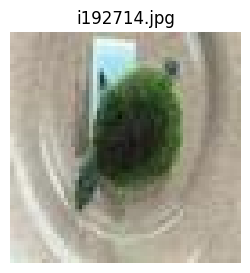

Title: My boyfriend gave me a turtle, and it suddenly grew hair these past two days. Should I brush it off
Tag: Pet Reptiles
Description: Should I brush it off?


In [10]:
def plot_item_image(image_filename, df, image_dir='recsys-pf/resized_images/'):
    image_filename = str(image_filename)
    search_pattern = os.path.join(image_dir, f"{image_filename}.*")
    matching_files = glob.glob(search_pattern)
    image_path = matching_files[0]
    img = Image.open(image_path)

    plt.figure(figsize=(3, 3))
    plt.imshow(img)
    plt.axis('off')
    plt.title(os.path.basename(image_path))
    plt.savefig('turtle.jpg')
    plt.show()
    item_row = df[df['item_id'] == image_filename]
    print("Title:", item_row.iloc[0]['title'])
    print("Tag:", item_row.iloc[0]['tag'])
    print("Description:", item_row.iloc[0]['description'])


sample_filename = item_info_df['item_id'].iloc[0]
plot_item_image(sample_filename, item_info_df)

# 2. Distribuciones

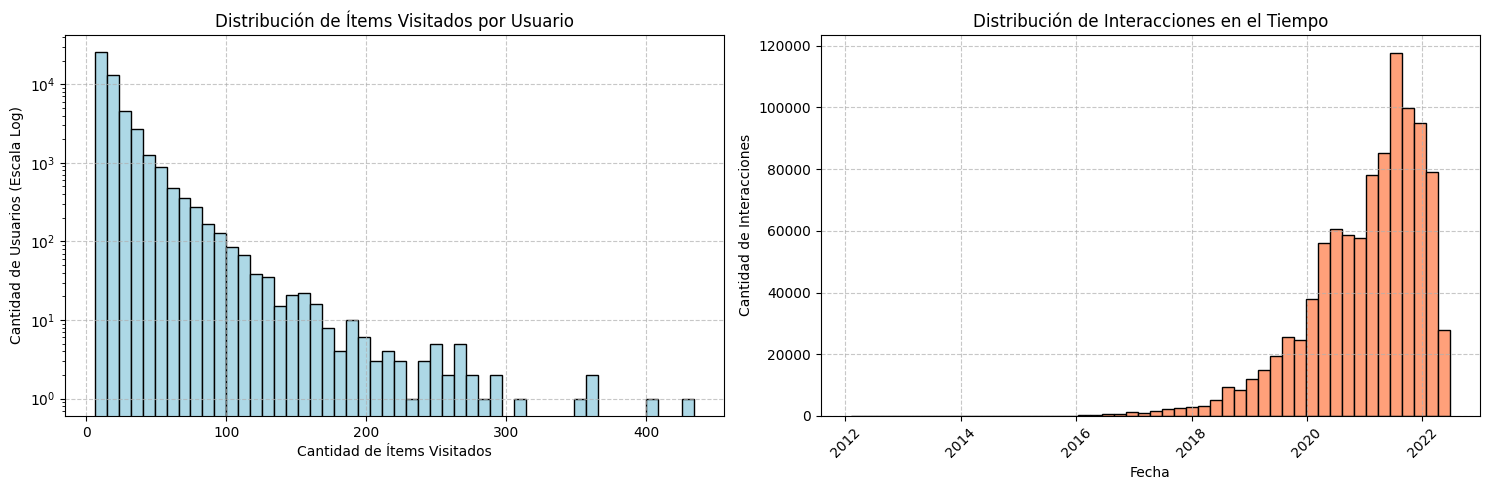

In [ ]:
items_per_user = interaction_df.groupby('user_id')['item_id'].count()

interaction_df['datetime'] = pd.to_datetime(interaction_df['timestamp'], unit='s')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(items_per_user, bins=50, color='lightblue', edgecolor='black')
axes[0].set_title('Distribución de Ítems Visitados por Usuario')
axes[0].set_xlabel('Cantidad de Ítems Visitados')
axes[0].set_ylabel('Cantidad de Usuarios (Escala Log)')
axes[0].set_yscale('log')
axes[0].grid(True, linestyle='--', alpha=0.7)

axes[1].hist(interaction_df['datetime'], bins=50, color='lightsalmon', edgecolor='black')
axes[1].set_title('Distribución de Interacciones en el Tiempo')
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel('Cantidad de Interacciones')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

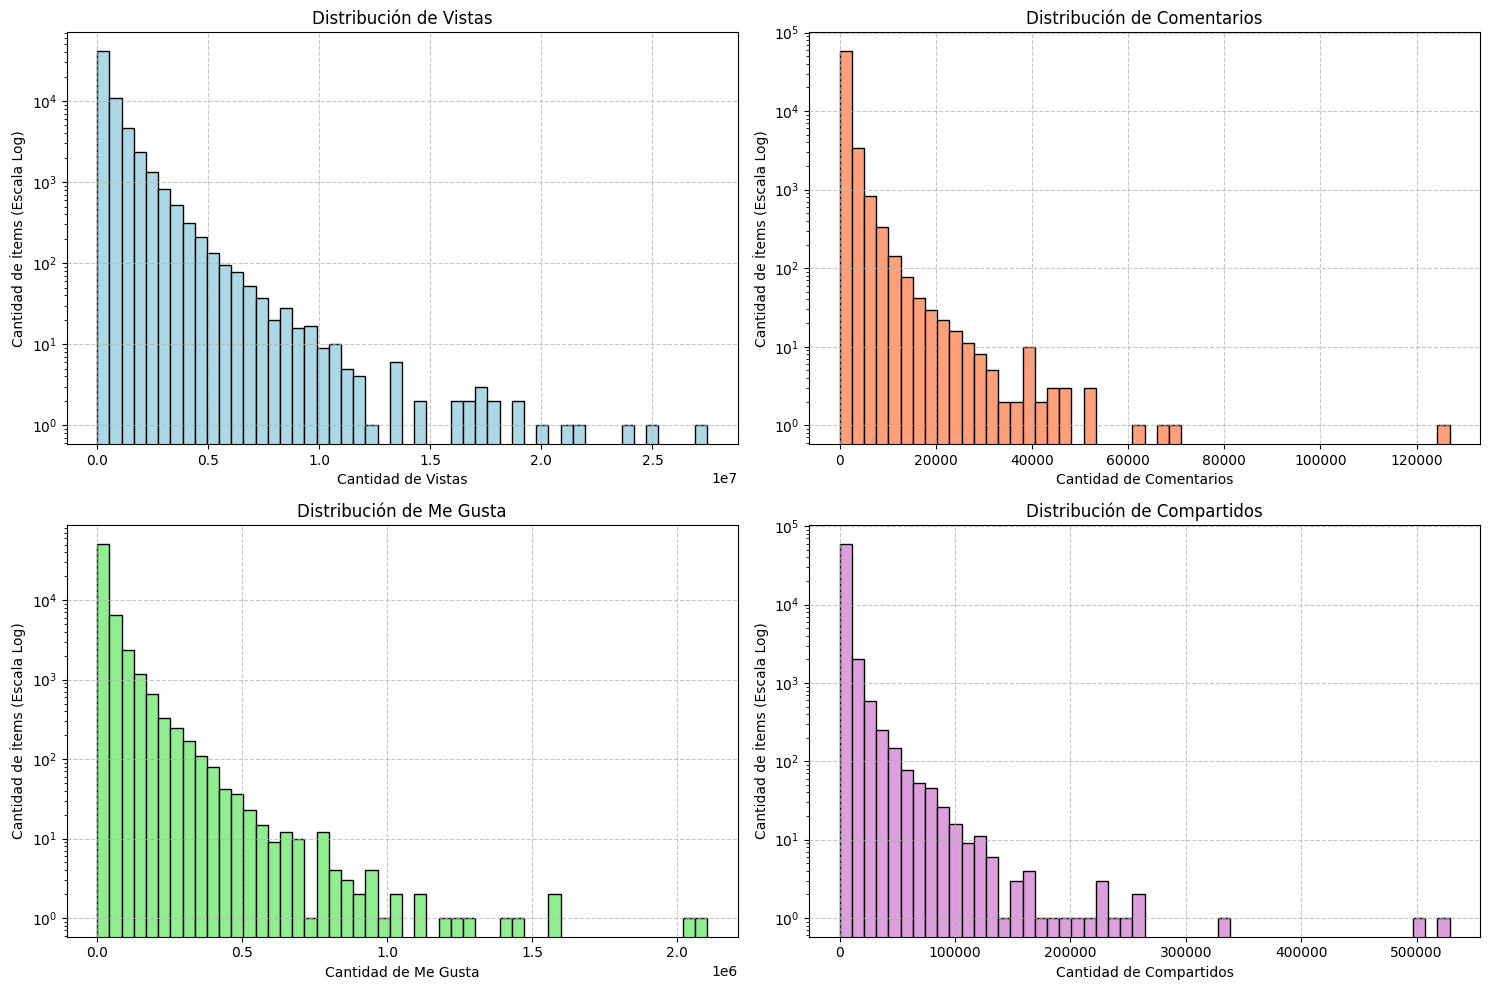

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

metricas = ['view_number', 'comment_number', 'thumbup_number', 'share_number']
colores = ['lightblue', 'lightsalmon', 'lightgreen', 'plum']
titulos = ['Vistas', 'Comentarios', 'Me Gusta', 'Compartidos']

for i, metrica in enumerate(metricas):
    axes[i].hist(item_info_df[metrica], bins=50, color=colores[i], edgecolor='black', log=True)

    axes[i].set_title(f'Distribución de {titulos[i]}')
    axes[i].set_xlabel(f'Cantidad de {titulos[i]}')
    axes[i].set_ylabel('Cantidad de Ítems (Escala Log)')
    axes[i].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

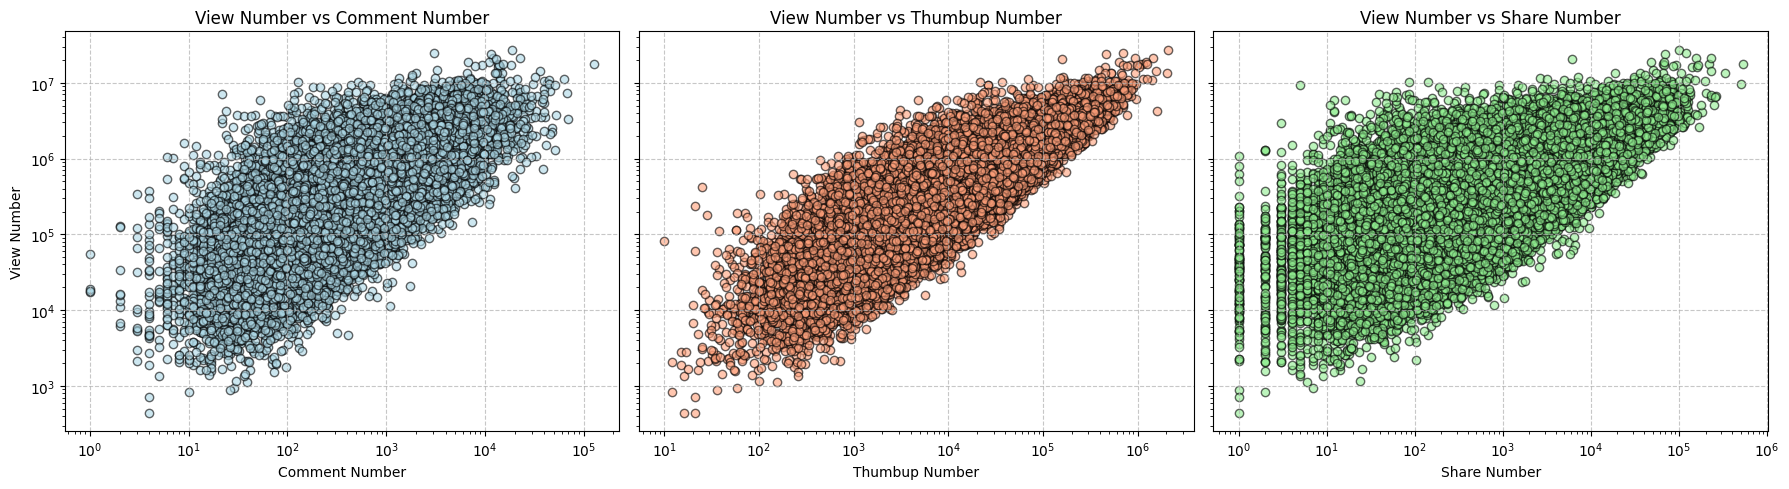

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

axes[0].scatter(item_info_df['comment_number'], item_info_df['view_number'], color='lightblue', alpha=0.6, edgecolor='black')
axes[0].set_title('View Number vs Comment Number')
axes[0].set_xlabel('Comment Number')
axes[0].set_ylabel('View Number')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].grid(True, linestyle='--', alpha=0.7)

axes[1].scatter(item_info_df['thumbup_number'], item_info_df['view_number'], color='lightsalmon', alpha=0.6, edgecolor='black')
axes[1].set_title('View Number vs Thumbup Number')
axes[1].set_xlabel('Thumbup Number')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].grid(True, linestyle='--', alpha=0.7)

axes[2].scatter(item_info_df['share_number'], item_info_df['view_number'], color='lightgreen', alpha=0.6, edgecolor='black')
axes[2].set_title('View Number vs Share Number')
axes[2].set_xlabel('Share Number')
axes[2].set_xscale('log')
axes[2].set_yscale('log')
axes[2].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()